##### Importing core libraries



In [2]:
!pip install "numpy<2" "pandas>=2.2.2" "shap<0.45" scikit-learn matplotlib seaborn streamlit

In [3]:
import numpy as np # for numerical operations
import pandas as pd # for dataframe
import os # for saving final results

##### Importing visualization libraries

In [5]:
import matplotlib.pyplot as plt # for plotting basic charts
import seaborn as sns # for statistical plotting
import shap
shap.initjs()

C:\Users\Hp\Churn model\churn_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Machine learning utilities

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [8]:
# Persistence
import pickle

# Notebook display options (make tables fully visible)
pd.set_option("display.max_columns", 200)


##### Loading dataset and inspect

In [10]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### Quick data check : shape, dtype, missing values

In [12]:
#Basic info of the date
print("Shape: ",df.shape)
print("\nData type:\n",df.dtypes)

#Count missing values
print("\nMissing value:\n",df.isnull().sum())

#can use df.info() also

Shape:  (7043, 21)

Data type:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing value:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract           

##### Cleaning obvious issues: TotalCharges is a string

In [14]:
# Convert 'TotalCharges' column values to numeric values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

# Now check again for missing values in the 'TotalCharges' column
print("TotalCharges missing:",df['TotalCharges'].isnull().sum())

TotalCharges missing: 11


##### Handle missing values

In [16]:
# If missing values are few, we can drop those rows.

missing_total = df['TotalCharges'].isnull().sum()
missing_pct = missing_total / len(df)

if missing_total > 0 and missing_pct > 0.01:
    # drop rows with missing TotalCharges if more than 1% of the data is missing
    df = df.dropna(subset=['TotalCharges'])
elif missing_total > 0:
    # otherwise, fill using median
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


##### Convert target column to numeric

In [18]:
# Map target to binary
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

#Quick check: distribution of target
print(df['Churn'].value_counts(normalize=True))

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


##### Quick EDA: univariate and bivariate analysis

In [20]:
#Numeric summary for numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.000,0.000,1.00,1.00


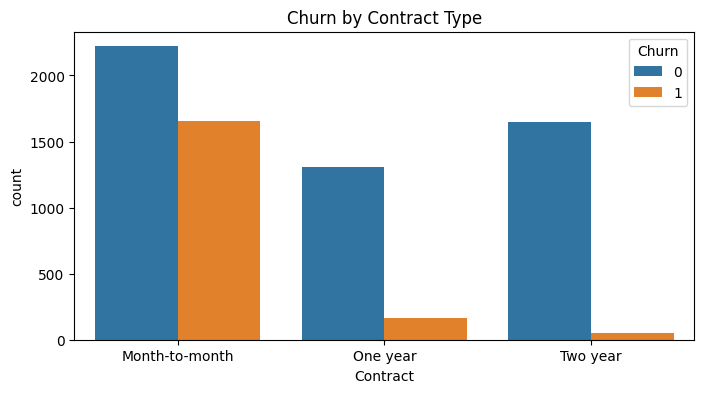

In [21]:
#Plot churn rate by Contract type (categorical)
plt.figure(figsize=(8,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

##### Feature Selection

In [23]:
features = [ 
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod'
]

# Confirm if all features exist in df
missing_features = [col for col in features if col not in df.columns]
if missing_features:
    raise ValueError(f"Missing features: {missing_features}")


##### Train/validation/test split

In [25]:
X = df[features]
y = df['Churn']

# Split: 60% train, 20% validation, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (4225, 8)
Validation shape: (1409, 8)
Test shape: (1409, 8)


##### Preprocessing: numerical vs categorical pipelines

In [27]:
# Identify numeric and categorical features from our selected list
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in features if col not in numeric_features]

# Numeric pipeline: scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: encode categorical variables
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


##### Create modelling pipelines and hyperparameter grids

In [29]:
# Logistic regression pipeline (interpretable, fast)
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Random forest pipeline (stronger, non-linear)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Hyperparameter grids for GridSearchCV
logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': [None, 'balanced']
}


##### GridSearchCV on training set only

In [31]:
def run_grid_search(name, pipeline, param_grid, X_train, y_train):
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    grid.fit(X_train, y_train)
    print(f"=== {name} GridSearchCV ===")
    print("Best CV AUC:", round(grid.best_score_, 4))
    print("Best params:", grid.best_params_)
    return grid

logreg_grid = run_grid_search("Logistic Regression", logreg_pipeline, logreg_param_grid, X_train, y_train)
rf_grid = run_grid_search("Random Forest", rf_pipeline, rf_param_grid, X_train, y_train)


=== Logistic Regression GridSearchCV ===
Best CV AUC: 0.8441
Best params: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}
=== Random Forest GridSearchCV ===
Best CV AUC: 0.8476
Best params: {'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


##### Evaluate tuned models on the validation set

In [33]:
# Define a helper function to print metrics
def evaluate_model(pipe, X_data, y_data, name='model'):
    y_pred = pipe.predict(X_data)
    y_proba = pipe.predict_proba(X_data)[:, 1]
    print(f"==={name}===")
    print("Accuracy", accuracy_score(y_data, y_pred))
    print("Precision", precision_score(y_data, y_pred))
    print("Recall", recall_score(y_data, y_pred))
    print("F1", f1_score(y_data, y_pred))
    print("ROC AUC", roc_auc_score(y_data, y_proba))
    print("\nClassification report:\n", classification_report(y_data, y_pred))
    return y_proba

# Predict probabilities on validation data
y_val_proba_log = evaluate_model(logreg_grid.best_estimator_, X_val, y_val, "Logistic Regression (validation)")
y_val_proba_rf = evaluate_model(rf_grid.best_estimator_, X_val, y_val, "Random Forest (validation)")


===Logistic Regression (validation)===
Accuracy 0.8034066713981547
Precision 0.6549520766773163
Recall 0.5481283422459893
F1 0.5967976710334789
ROC AUC 0.8346030638869513

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

===Random Forest (validation)===
Accuracy 0.7984386089425124
Precision 0.6890756302521008
Recall 0.4385026737967914
F1 0.5359477124183006
ROC AUC 0.836169882972952

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87      1035
           1       0.69      0.44      0.54       374

    accuracy                           0.80      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg    

##### Pick best model based on validation ROC-AUC

In [35]:
auc_lr = roc_auc_score(y_val, y_val_proba_log)
auc_rf = roc_auc_score(y_val, y_val_proba_rf)
print("AUC - LogReg", auc_lr, "RF", auc_rf)

if auc_lr >= auc_rf:
    best_name = "Logistic Regression"
    best_pipeline_val = logreg_grid.best_estimator_
    best_val_proba = y_val_proba_log
else:
    best_name = "Random Forest"
    best_pipeline_val = rf_grid.best_estimator_
    best_val_proba = y_val_proba_rf

print("Selected best model:", best_name)


AUC - LogReg 0.8346030638869513 RF 0.836169882972952
Selected best model: Random Forest


##### Refit selected model on train + validation for final deployment model

In [37]:
# Refit the selected model on all non-test data
trainval_X = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
trainval_y = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

best_pipeline = clone(best_pipeline_val)
best_pipeline.fit(trainval_X, trainval_y)

print("Final pipeline refit on train + validation data.")


Final pipeline refit on train + validation data.


##### Model explainability (feature importance + simple local explanation)

Number of features after transform: 19
Sample feature names: ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No']


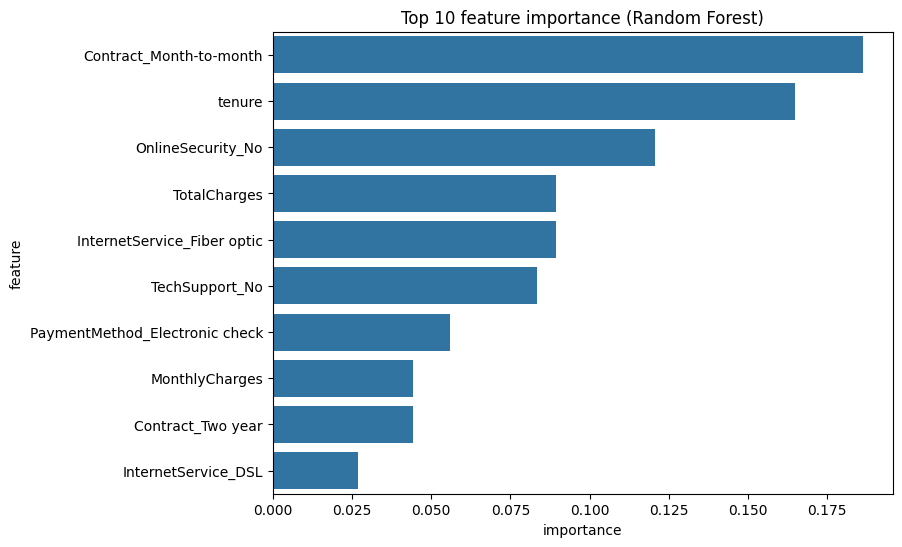

In [39]:
# Feature name extraction
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
feature_names = preprocessor_fitted.get_feature_names_out()
feature_names = [fn.replace('num__', '').replace('cat__', '') for fn in feature_names]
print("Number of features after transform:", len(feature_names))
print("Sample feature names:", feature_names[:10])

# Feature importance display
if best_name == "Random Forest":
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi_df.head(10), x='importance', y='feature')
    plt.title("Top 10 feature importance (Random Forest)")
    plt.show()
else:
    coeffs = best_pipeline.named_steps['classifier'].coef_[0]
    fi_df = pd.DataFrame({'feature': feature_names, 'coefficient': coeffs})
    fi_df['abs_coef'] = fi_df['coefficient'].abs()
    fi_df = fi_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

    display(fi_df.head(15))
    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi_df.head(10), x='coefficient', y='feature')
    plt.title("Top 10 coefficients (Logistic Regression)")
    plt.show()


##### SHAP Explainability

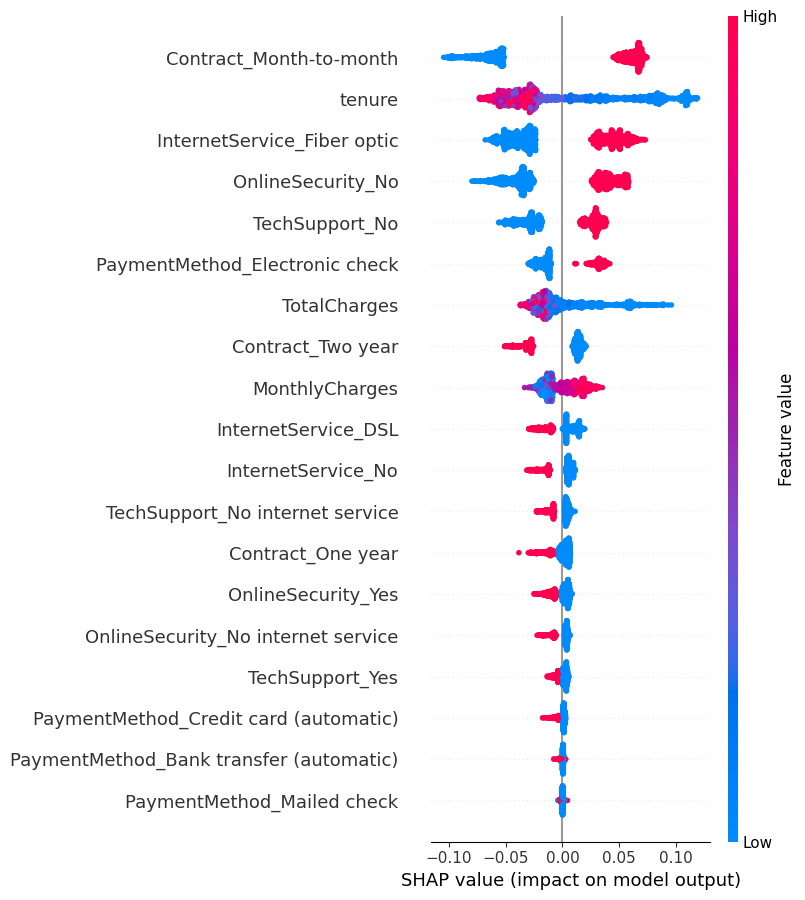

In [41]:
# SHAP explanation
# Use test data only after model/threshold selection is complete
X_test_transformed = preprocessor_fitted.transform(X_test)

if best_name == "Random Forest":
    explainer = shap.TreeExplainer(best_pipeline.named_steps['classifier'])
    shap_values_all = explainer.shap_values(X_test_transformed)
    if isinstance(shap_values_all, np.ndarray) and shap_values_all.ndim == 3:
        shap_values = shap_values_all[:,:,1]
    else:
        shap_values = shap_values_all
else:
    # For LogisticRegression, use LinearExplainer when possible
    X_background = preprocessor_fitted.transform(
        trainval_X.sample(min(200, len(trainval_X)), random_state=42)
    )
    try:
        explainer = shap.LinearExplainer(best_pipeline.named_steps['classifier'], X_background)
        shap_values_all = explainer.shap_values(X_test_transformed)
        if isinstance(shap_values_all, np.ndarray) and shap_values_all.ndim == 3:
            shap_values = shap_values_all[:,:,1]
    except Exception:
        explainer = shap.KernelExplainer(
            best_pipeline.named_steps['classifier'].predict_proba,
            X_background
        )
        shap_values_all = explainer.shap_values(X_test_transformed)
        if isinstance(shap_values_all, np.ndarray) and shap_values_all.ndim == 3:
            shap_values = shap_values_all[:,:,1]
            
# Global summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=True)

# Local explanation
i = 0
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

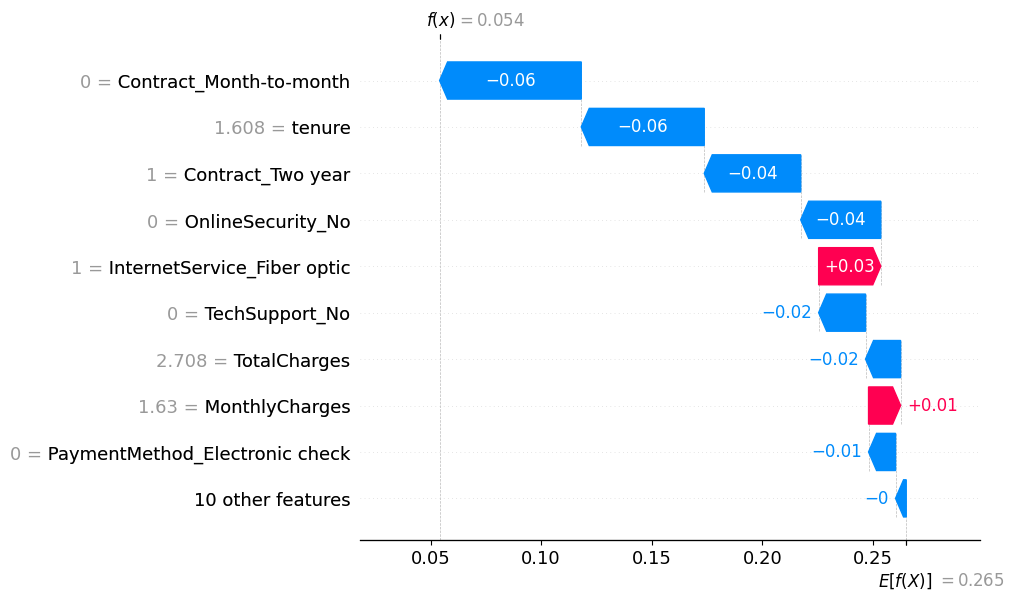

In [42]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[i],
    base_values=base_value,
    data=X_test_transformed[i],
    feature_names=feature_names
))


##### Profit Curve

Best threshold: 0.350, Best profit (annual): ₹30048.00


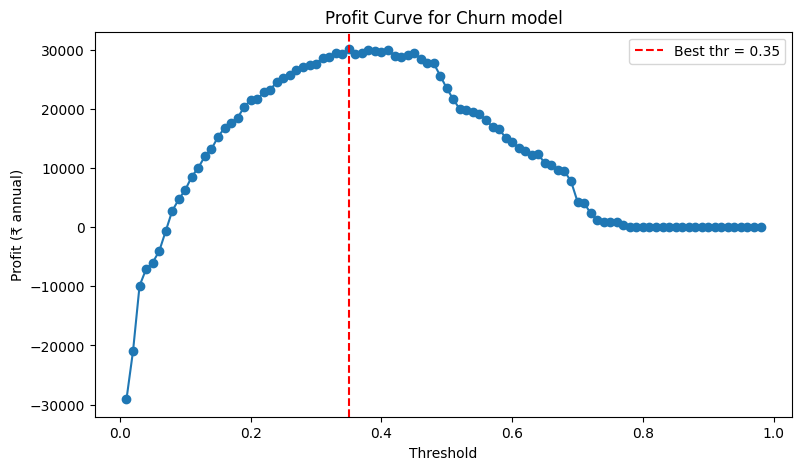

In [44]:
# Get validation probabilities for business threshold tuning
y_val_proba = best_val_proba

# Business assumptions - change to realistic values for business
avg_revenue_per_customer = 80.0  # monthly average revenue per customer (₹)
cost_of_retention_offer = 100.0  # cost of offering retention (realistic cost: discounted plan or agent time) (₹)

thresholds = np.arange(0.01, 0.99, 0.01)
profits = []

for thr in thresholds:
    pred = (y_val_proba >= thr).astype(int)
    tp = ((y_val == 1) & (pred == 1)).sum()
    fp = ((y_val == 0) & (pred == 1)).sum()
    retention_success_rate   = 0.30    # only 30% of interventions succeed
    prevented_revenue = tp * avg_revenue_per_customer * 12 * retention_success_rate
    cost_of_offers    = (tp + fp) * cost_of_retention_offer
    profit = prevented_revenue - cost_of_offers
    profits.append(profit)

best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

print(f"Best threshold: {best_threshold:.3f}, Best profit (annual): ₹{best_profit:.2f}")

# Plot profit curve
plt.figure(figsize=(9, 5))
plt.plot(thresholds, profits, marker='o')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best thr = {best_threshold:.2f}')
plt.xlabel("Threshold")
plt.ylabel("Profit (₹ annual)")
plt.title("Profit Curve for Churn model")
plt.legend()
plt.show()


#### Profit simulation shows that the threshold is chosen on validation data, so the test set stays untouched until final evaluation.

##### Confusion matrix and metrics at best threshold

In [47]:
# Final evaluation on the untouched test set
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]
final_pred = (y_test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report (at best threshold):")
print(classification_report(y_test, final_pred))

tp = ((y_test == 1) & (final_pred == 1)).sum()
fp = ((y_test == 0) & (final_pred == 1)).sum()
fn = ((y_test == 1) & (final_pred == 0)).sum()
tn = ((y_test == 0) & (final_pred == 0)).sum()
print(f"TP {tp}, FP {fp}, FN {fn}, TN {tn}")


Confusion Matrix:
 [[819 216]
 [104 270]]

Classification Report (at best threshold):
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

TP 270, FP 216, FN 104, TN 819


##### Business ranking table(top X% customers)

In [49]:
# Customer risk ranking and top percentile selection
results = X_test.copy()
results['Actual Churn'] = y_test.values
results['Churn_probability'] = y_test_proba
results_sorted = results.sort_values('Churn_probability', ascending=False).reset_index(drop=True)
results_sorted['Rank'] = results_sorted.index + 1

top_pct = 0.10
top_n = int(len(results_sorted) * top_pct)
top_customers = results_sorted.head(top_n)

print(f"Top {top_pct * 100}% customers = {top_n} rows")
print("Churn rate in top group:", top_customers['Actual Churn'].mean())
top_customers.head(10)


Top 10.0% customers = 140 rows
Churn rate in top group: 0.7071428571428572


,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,Actual Churn,Churn_probability,Rank
0,1,89.55,89.55,Month-to-month,Fiber optic,No,No,Electronic check,1,0.760731,1
1,1,79.50,79.50,Month-to-month,Fiber optic,No,No,Electronic check,1,0.758833,2
2,1,80.00,80.00,Month-to-month,Fiber optic,No,No,Electronic check,1,0.758833,3
3,1,80.50,80.50,Month-to-month,Fiber optic,No,No,Electronic check,1,0.758833,4
4,1,85.00,85.00,Month-to-month,Fiber optic,No,No,Electronic check,0,0.758071,5
5,1,88.35,88.35,Month-to-month,Fiber optic,No,No,Electronic check,1,0.758071,6
6,1,85.00,85.00,Month-to-month,Fiber optic,No,No,Electronic check,1,0.758071,7
7,1,84.85,84.85,Month-to-month,Fiber optic,No,No,Electronic check,1,0.758071,8
8,1,85.05,85.05,Month-to-month,Fiber optic,No,No,Electronic check,1,0.758071,9
9,1,78.80,78.80,Month-to-month,Fiber optic,No,No,Electronic check,1,0.757886,10


##### Saving best pipeline to disk (for deployment)

In [51]:
# Save final model + threshold
model_data = {
    "model": best_pipeline,
    "threshold": best_threshold
}

with open("churn_best_pipeline.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Saved final pipeline to: churn_best_pipeline.pkl")


Saved final pipeline to: churn_best_pipeline.pkl
